# Why Chebyshev interpolation works

chebax's recipes can look like a bag of one-off tricks: a table for J, a
log-table for K, a tensor for the Beta function. This notebook is about
the machinery underneath, and its point is that nothing there is specific
to those functions. Polynomial interpolation approximates *any* smooth
function on a finite interval essentially as well as any polynomial can,
provided one thing is done right: **where you sample**.

Interpolating at $n+1$ nodes $x_k$ makes the error proportional to the
node polynomial $\prod_k (x - x_k)$. For equispaced nodes that product is
astronomically lopsided: tiny in the middle of the interval, enormous near
the ends, and it gets *worse* as $n$ grows. That is Runge's phenomenon,
and it is why polynomial interpolation has an undeserved bad reputation.

Chebyshev points,

$$x_k = \cos\left(\tfrac{k\pi}{n}\right), \qquad k = 0, \dots, n,$$

cluster near the endpoints exactly like $1/\sqrt{1-x^2}$, which makes the
node polynomial uniformly small — as small as any monic polynomial can be
on the interval. Two classical consequences (Trefethen, *Approximation
Theory and Approximation Practice*):

- **Near-minimax.** The Chebyshev interpolant is within a factor
  $1 + \Lambda_n$ of the *best possible* degree-$n$ polynomial, with
  $\Lambda_n \approx \tfrac{2}{\pi}\ln n + 0.98 < 4$ at any practical
  degree. Choosing better coefficients than interpolation-at-Chebyshev-
  points can win you at most a factor of a few, never orders of magnitude.
- **Geometric convergence.** If $f$ is analytic in a neighborhood of the
  interval (a Bernstein ellipse of parameter $\rho > 1$), the error decays
  like $\rho^{-n}$; for entire functions it decays faster than any
  geometric rate. Doubling the degree squares the error. Machine precision
  is a few doublings away, for any such $f$.

n =  10: max error equispaced  1.92e+00   Chebyshev  1.09e-01
n =  20: max error equispaced  5.98e+01   Chebyshev  1.53e-02
n =  40: max error equispaced  1.05e+05   Chebyshev  2.89e-04


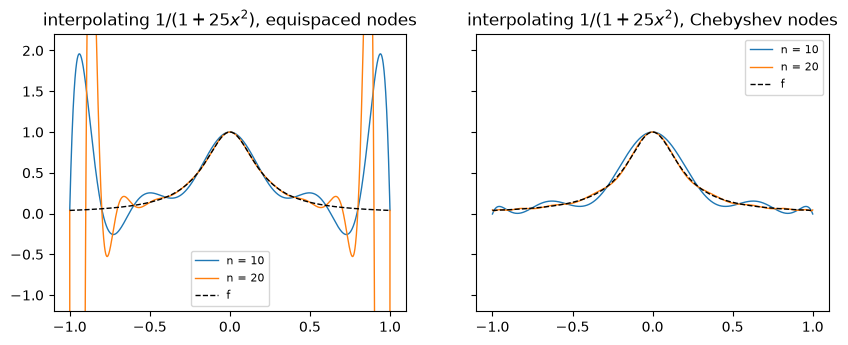

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)

import chebax


def bary_interp(xn, yn, x):
    # barycentric Lagrange interpolation: numerically stable evaluation of
    # THE interpolating polynomial through (xn, yn), whatever the nodes
    c = np.ones_like(xn)
    for j, xj in enumerate(xn):
        c[j] = 1.0 / np.prod(xj - np.delete(xn, j))
    num = np.zeros_like(x)
    den = np.zeros_like(x)
    exact = np.full(x.shape, -1)
    for j, (xj, yj, cj) in enumerate(zip(xn, yn, c)):
        d = x - xj
        exact = np.where(d == 0, j, exact)
        with np.errstate(divide="ignore", invalid="ignore"):
            w = cj / d
        num += np.where(d == 0, 0.0, w) * yj
        den += np.where(d == 0, 0.0, w)
    y = num / den
    hit = exact >= 0
    y[hit] = yn[exact[hit]]
    return y


runge = lambda x: 1.0 / (1.0 + 25.0 * x * x)
xx = np.linspace(-1, 1, 2001)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
for n in (10, 20):
    xe = np.linspace(-1, 1, n + 1)
    ye = bary_interp(xe, runge(xe), xx)
    p = chebax.fit(runge, deg=n)          # interpolation at Chebyshev points
    axes[0].plot(xx, ye, lw=1, label=f"n = {n}")
    axes[1].plot(xx, np.asarray(p(xx)), lw=1, label=f"n = {n}")
for ax, title in zip(axes, ["equispaced nodes", "Chebyshev nodes"]):
    ax.plot(xx, runge(xx), "k--", lw=1, label="f")
    ax.set_title(f"interpolating $1/(1+25x^2)$, {title}")
    ax.legend(fontsize=8)
axes[0].set_ylim(-1.2, 2.2)

for n in (10, 20, 40):
    xe = np.linspace(-1, 1, n + 1)
    err_e = np.abs(bary_interp(xe, runge(xe), xx) - runge(xx)).max()
    err_c = float(jnp.max(jnp.abs(chebax.fit(runge, deg=n)(xx) - runge(xx))))
    print(f"n = {n:3d}: max error equispaced {err_e:9.2e}   Chebyshev {err_c:9.2e}")

Same function, same degrees, same interpolation problem; the only change
is the nodes. Equispaced interpolation *diverges* as the degree grows;
Chebyshev interpolation converges geometrically.

## Convergence to the floating-point floor

The rate is set by how far the function's singularities sit from the
interval, and the error keeps halving-then-squaring until it runs into
float64 itself. Three regimes: the Runge function is analytic with poles
at $\pm i/5$ (plain geometric), $\cos 20x$ is entire but oscillatory
(nothing happens until the degree resolves the oscillations, then the
error plunges), $e^x$ is entire and tame (super-geometric from the
start).

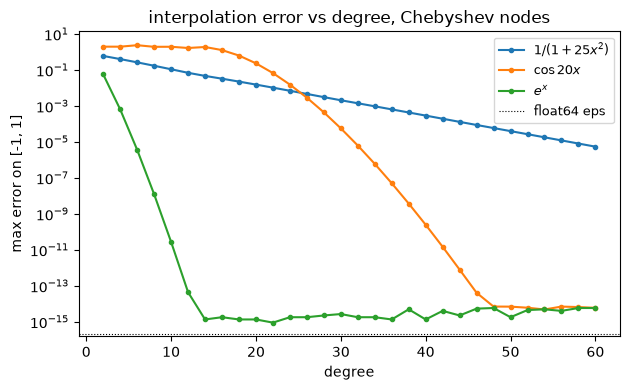

In [2]:
targets = [
    (r"$1/(1+25x^2)$", runge),
    (r"$\cos 20x$", lambda x: np.cos(20.0 * x)),
    (r"$e^x$", np.exp),
]
degs = np.arange(2, 62, 2)
plt.figure(figsize=(6.4, 4))
for name, f in targets:
    errs = [float(jnp.max(jnp.abs(chebax.fit(f, deg=int(n))(xx) - f(xx))))
            for n in degs]
    plt.semilogy(degs, errs, "o-", ms=3, label=name)
plt.axhline(2.2e-16, color="k", lw=0.8, ls=":", label="float64 eps")
plt.xlabel("degree"); plt.ylabel("max error on [-1, 1]")
plt.legend(fontsize=9); plt.title("interpolation error vs degree, Chebyshev nodes")
plt.tight_layout()

## An arbitrary function, not a baked recipe

To make the "this is general" point concrete, here is a function chebax
has no recipe for: $f(x) = J_{3.1}(x) + K_{2.5}(x)$ on $[0.5, 12]$. The
two recipe objects only supply *values* of $f$; `chebax.fit` sees nothing
but a black-box callable, picks the degree adaptively (doubling nodes and
validating against fresh off-grid samples until the coefficient tail hits
the noise floor), and returns one plain polynomial.

adaptive degree: 97
max |p - f| / max|f| on a 4001-point grid: 3.30e-15


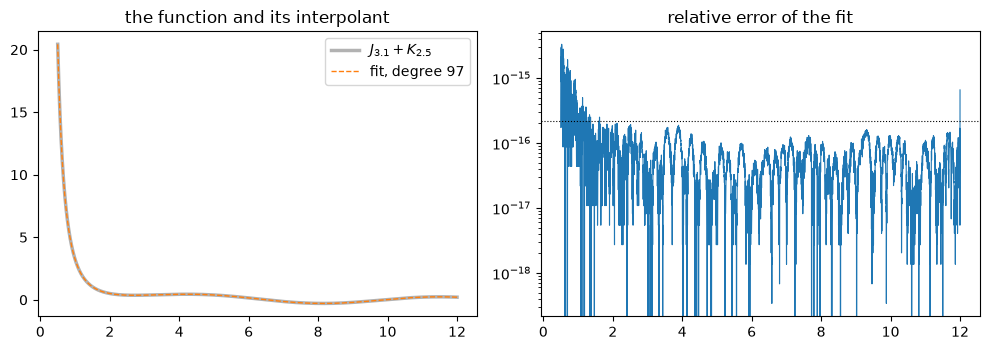

In [3]:
jv = chebax.besselj(3.1)
kv = chebax.besselk(2.5)
f = lambda x: np.asarray(jv(x)) + np.asarray(kv(x))

p = chebax.fit(f, domain=(0.5, 12.0))
xg = np.linspace(0.5, 12.0, 4001)
err = np.abs(np.asarray(p(xg)) - f(xg))
scale = np.abs(f(xg)).max()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot(xg, f(xg), "k", lw=2.5, alpha=0.3, label="$J_{3.1}+K_{2.5}$")
axes[0].plot(xg, np.asarray(p(xg)), "C1--", lw=1, label=f"fit, degree {p.degree}")
axes[0].legend(); axes[0].set_title("the function and its interpolant")
axes[1].semilogy(xg, err / scale, lw=0.8)
axes[1].axhline(2.2e-16, color="k", lw=0.8, ls=":")
axes[1].set_title("relative error of the fit")
plt.tight_layout()
print(f"adaptive degree: {p.degree}")
print(f"max |p - f| / max|f| on a 4001-point grid: {err.max() / scale:.2e}")

A few dozen coefficients, picked automatically, and the interpolant is
indistinguishable from the target at float64 resolution. The same call
works for any smooth function on a finite interval: a likelihood, a
partition function, an integral you can only evaluate numerically.

## Derivatives come out looking analytical

The derivative of a Chebyshev series is another Chebyshev series, with
coefficients given by an exact three-term recurrence (`chebder`) — no
finite differences anywhere. So `p.deriv()` is the same *kind* of object
as `p`, and its accuracy is set by the approximation, not by a step size.
This is the property that makes the whole library compose with
autodifferentiation: `jax.grad` through the recipes' Clenshaw evaluation
produces the same polynomial that the coefficient recurrence produces.

max relative derivative error: 7.10e-14


second derivative at x=3: +0.141852789574 (one more exact recurrence, no extra cost in kind)


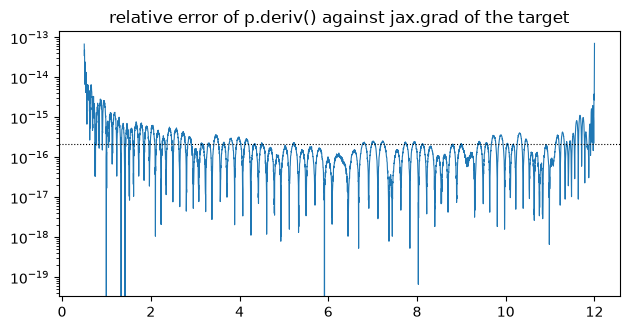

In [4]:
# reference derivative: jax.grad through the recipe objects (custom_jvp
# bound to their exact derivative series)
df_ref = jax.vmap(jax.grad(lambda x: jv(x) + kv(x)))(jnp.asarray(xg))
dp = p.deriv()
derr = np.abs(np.asarray(dp(xg)) - np.asarray(df_ref))
dscale = np.abs(np.asarray(df_ref)).max()

plt.figure(figsize=(6.4, 3.4))
plt.semilogy(xg, derr / dscale, lw=0.8)
plt.axhline(2.2e-16, color="k", lw=0.8, ls=":")
plt.title("relative error of p.deriv() against jax.grad of the target")
plt.tight_layout()
print(f"max relative derivative error: {derr.max() / dscale:.2e}")
print(f"second derivative at x=3: {float(dp.deriv()(3.0)):+.12f} "
      f"(one more exact recurrence, no extra cost in kind)")

The derivative error sits a little above the value error — differentiating
amplifies the float64 sampling noise of the build by roughly the square of
the degree. When that floor matters, `chebax.fit(..., dps=40)` samples and
transforms in extended precision and removes it; the baked recipes are all
built that way.

## What is general, and what is not

General: any function that is smooth on a finite interval, however it is
computed, interpolated at Chebyshev points, converges near-optimally and
reaches the floating-point floor at a modest degree, together with its
derivatives. That is a theorem, not a property of Bessel functions.

Not automatic: singular points and infinite domains. $K_\nu$'s
$x = 0$ branch point or $J_\nu$'s oscillatory tail to $x = 10^4$ are not
smooth-on-a-finite-interval problems; the recipes earn their keep by
transforming them into ones that are (factoring out branch behavior,
log-tabulating, phase/modulus splits). That per-family analysis is the
craft documented in `docs/adding-a-recipe.md`; the machinery this notebook
showed is everything else, and it is the same machinery for every
function.